
# Plots


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os

In [2]:
import sys
sys.path.append("..")

In [3]:
from sources.simulation import numerical_solution, euler_maruyama
from sources.plotting import *
from sources.analysis import *
from sources.models import *
from sources.data_storage import *

## Global settings

In [4]:
from pathlib import Path
import subprocess

import matplotlib as mpl
import matplotlib.pyplot as plt


# ============================================================
# Report output directory
# ============================================================

# Find the root of the Git repository, regardless of where
# this notebook is located inside the project.
PROJECT_ROOT = Path(
    subprocess.check_output(
        ["git", "rev-parse", "--show-toplevel"],
        text=True
    ).strip()
)

REPORT_1D_DIR = PROJECT_ROOT / "report_1dplots"
REPORT_1D_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Base plotting values
# ============================================================

BASE_FONT_SIZE = 10
BASE_TICK_SIZE = 9
BASE_LEGEND_SIZE = 9

BASE_LINEWIDTH = 1.5
BASE_MARKERSIZE = 4.5

BASE_AXES_LINEWIDTH = 0.8
BASE_MAJOR_TICK_WIDTH = 0.8
BASE_MINOR_TICK_WIDTH = 0.6

BASE_GRID_LINEWIDTH = 0.5


# ============================================================
# Dissertation plotting style
# ============================================================

mpl.rcParams.update({

    # LaTeX / fonts
    "text.usetex": True,
    "font.family": "serif",

    "font.size": BASE_FONT_SIZE,
    "axes.titlesize": BASE_FONT_SIZE,
    "axes.labelsize": BASE_FONT_SIZE,
    "xtick.labelsize": BASE_TICK_SIZE,
    "ytick.labelsize": BASE_TICK_SIZE,
    "legend.fontsize": BASE_LEGEND_SIZE,

    # Axes
    "axes.linewidth": BASE_AXES_LINEWIDTH,
    "axes.axisbelow": True,

    # Lines
    "lines.linewidth": BASE_LINEWIDTH,
    "lines.markersize": BASE_MARKERSIZE,

    # Ticks
    "xtick.direction": "out",
    "ytick.direction": "out",

    "xtick.major.width": BASE_MAJOR_TICK_WIDTH,
    "ytick.major.width": BASE_MAJOR_TICK_WIDTH,

    "xtick.minor.width": BASE_MINOR_TICK_WIDTH,
    "ytick.minor.width": BASE_MINOR_TICK_WIDTH,

    # Grid
    "grid.alpha": 0.22,
    "grid.linewidth": BASE_GRID_LINEWIDTH,

    # Legends
    "legend.frameon": False,

    # Figure display / saving
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "savefig.facecolor": "white",
})


# ============================================================
# Consistent plotting colours
# ============================================================

COLOR_REFLECTION = "tab:blue"
COLOR_REJECTION = "tab:orange"
COLOR_STATIONARY = "red"

COLOR_MIXED = "tab:green"
COLOR_HALF_STEP = "tab:purple"

COLOR_HISTOGRAM = "tab:blue"

HISTOGRAM_ALPHA = 0.90
STATIONARY_ALPHA = 0.90


# ============================================================
# Base report figure sizes
# ============================================================

FIGSIZE_SINGLE = (5.4, 3.6)
FIGSIZE_DOUBLE = (7.2, 3.4)
FIGSIZE_TRIPLE = (7.5, 3.2)
FIGSIZE_2X2 = (7.2, 5.3)


# ============================================================
# Uniform figure scaling
# ============================================================

def scaled_figsize(figsize, scale=1.0):
    """
    Scale the physical dimensions of a figure uniformly.
    """
    return tuple(value * scale for value in figsize)


def scaled_plot_style(scale=1.0):
    """
    Scale fonts, lines, markers, axes and ticks uniformly
    with the physical figure size.
    """
    return {
        "font.size": BASE_FONT_SIZE * scale,
        "axes.titlesize": BASE_FONT_SIZE * scale,
        "axes.labelsize": BASE_FONT_SIZE * scale,

        "xtick.labelsize": BASE_TICK_SIZE * scale,
        "ytick.labelsize": BASE_TICK_SIZE * scale,
        "legend.fontsize": BASE_LEGEND_SIZE * scale,

        "lines.linewidth": BASE_LINEWIDTH * scale,
        "lines.markersize": BASE_MARKERSIZE * scale,

        "axes.linewidth": BASE_AXES_LINEWIDTH * scale,

        "xtick.major.width": BASE_MAJOR_TICK_WIDTH * scale,
        "ytick.major.width": BASE_MAJOR_TICK_WIDTH * scale,

        "xtick.minor.width": BASE_MINOR_TICK_WIDTH * scale,
        "ytick.minor.width": BASE_MINOR_TICK_WIDTH * scale,

        "grid.linewidth": BASE_GRID_LINEWIDTH * scale,
    }

In [5]:
def save_report_figure(fig, filename, save_png=True):
    fig.savefig(REPORT_1D_DIR / f"{filename}.pdf")
    if save_png:
        fig.savefig(REPORT_1D_DIR / f"{filename}.png", dpi=300)

## Fig 1

In [6]:
#this is to make sure that lambda functions are deleted before defining new one
for var_name in ['b', 'sigma']:
    if var_name in locals():
        del locals()[var_name]

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions
b = lambda x: constant_drift(x, value=0)
sigma = lambda x: constant_diffusion(x, value=1) 

#these are used to load generated solutions
problem_path = "./data/b-0_s-1"
boundary_types = ["reflection", "rejection"]
dt_list = [0.16]#, 0.04, 0.01, 0.0025]

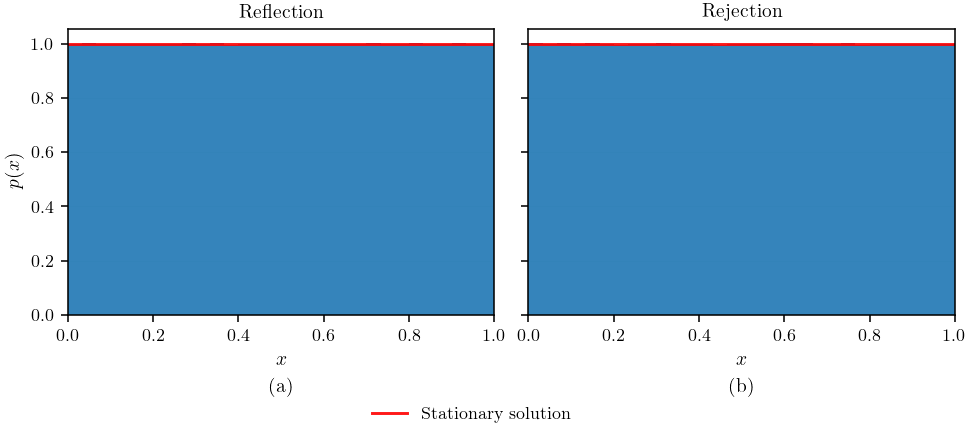

In [7]:
x_plot = np.linspace(x_bounds[0], x_bounds[1], 500)
p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

panel_labels = [r"(a)", r"(b)"]

# Figure-specific scale
figure_scale = 1.0


with mpl.rc_context(scaled_plot_style(figure_scale)):

    for dt in dt_list:

        fig, ax = plt.subplots(
            1, 2,
            figsize=scaled_figsize(
                FIGSIZE_DOUBLE,
                figure_scale
            ),
            sharex=True,
            sharey=True
        )

        stationary_line = None

        for i, boundary_type in enumerate(boundary_types):

            # Load the precomputed solution
            X = load_solution(
                f"{boundary_type}_dt-{dt}.npy",
                problem_path
            )

            # Histogram
            ax[i].hist(
                X,
                bins=30,
                density=True,
                color=COLOR_HISTOGRAM,
                alpha=HISTOGRAM_ALPHA,
                edgecolor="none"
            )

            # Exact stationary solution
            stationary_line, = ax[i].plot(
                x_plot,
                p_exact,
                color=COLOR_STATIONARY,
                label=r"Stationary solution",
                alpha=STATIONARY_ALPHA
            )

            # Axes formatting
            ax[i].set_title(
                boundary_name[boundary_type]
            )

            ax[i].set_xlabel(r"$x$")
            ax[i].set_xlim(x_bounds)
            ax[i].set_ylim(bottom=0)

            ax[i].grid(
                True,
                axis="y"
            )

            # Panel label
            ax[i].text(
                0.5,
                -0.22,
                panel_labels[i],
                transform=ax[i].transAxes,
                ha="center",
                va="top"
            )

        # Shared y-axis label
        ax[0].set_ylabel(r"$p(x)$")

        # Shared legend
        fig.legend(
            handles=[stationary_line],
            labels=[r"Stationary solution"],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=1
        )

        # Layout
        fig.subplots_adjust(
            left=0.10,
            right=0.98,
            top=0.88,
            bottom=0.28,
            wspace=0.08
        )

        # Save
        save_report_figure(
            fig,
            f"b-0_s-1_dt-{dt}"
        )

        plt.show()

## Fig 2 and 3

In [8]:
#this is to make sure that lambda functions are deleted before defining new one
for var_name in ['b', 'sigma']:
    if var_name in locals():
        del locals()[var_name]

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions
b = lambda x: constant_drift(x, value=1)
sigma = lambda x: constant_diffusion(x, value=1) 

#these are used to load generated solutions
problem_path = "./data/b-1_s-1"
boundary_types = ["reflection", "rejection"]
dt_list = [0.04, 0.0025]

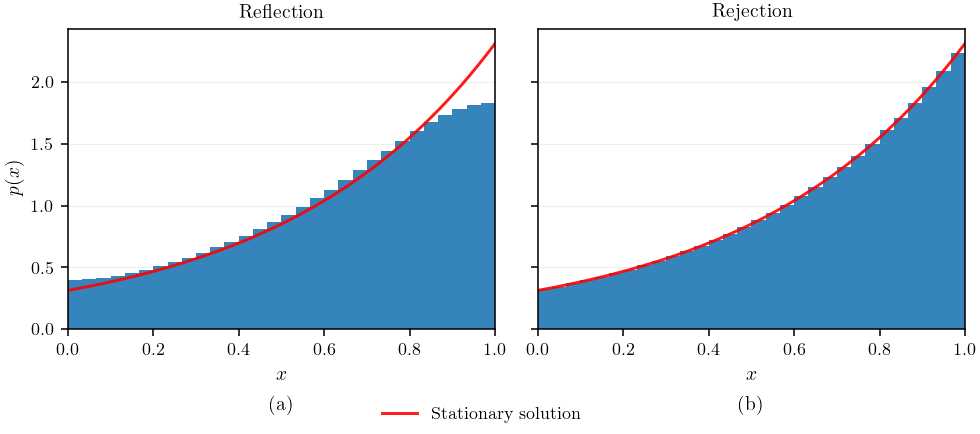

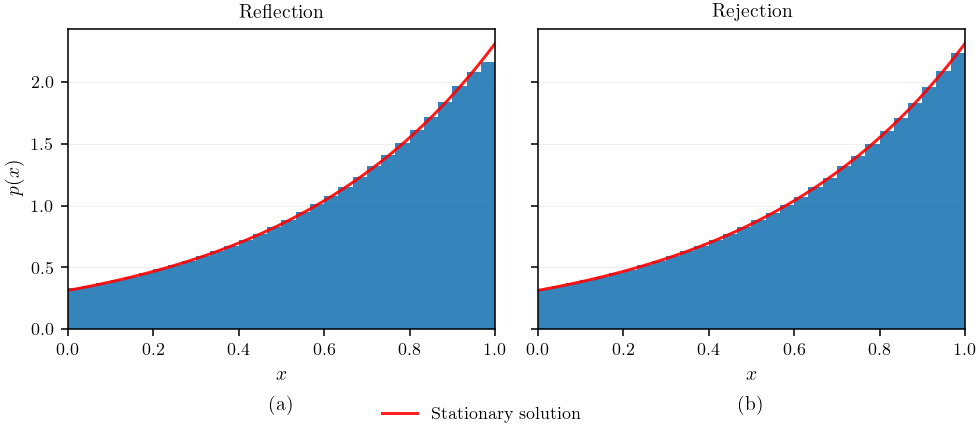

In [9]:
x_plot = np.linspace(x_bounds[0], x_bounds[1], 500)
p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

panel_labels = [r"(a)", r"(b)"]

# Figure-specific scale
figure_scale = 1.0


with mpl.rc_context(scaled_plot_style(figure_scale)):

    for dt in dt_list:

        fig, ax = plt.subplots(
            1, 2,
            figsize=scaled_figsize(
                FIGSIZE_DOUBLE,
                figure_scale
            ),
            sharex=True,
            sharey=True
        )

        stationary_line = None

        for i, boundary_type in enumerate(boundary_types):

            # Load the precomputed solution
            X = load_solution(
                f"{boundary_type}_dt-{dt}.npy",
                problem_path
            )

            # Histogram
            ax[i].hist(
                X,
                bins=30,
                density=True,
                color=COLOR_HISTOGRAM,
                alpha=HISTOGRAM_ALPHA,
                edgecolor="none"
            )

            # Exact stationary solution
            stationary_line, = ax[i].plot(
                x_plot,
                p_exact,
                color=COLOR_STATIONARY,
                alpha=STATIONARY_ALPHA,
                label=r"Stationary solution"
            )

            # Axes formatting
            ax[i].set_title(
                boundary_name[boundary_type]
            )

            ax[i].set_xlabel(r"$x$")
            ax[i].set_xlim(x_bounds)
            ax[i].set_ylim(bottom=0)

            # Light horizontal grid
            ax[i].grid(
                True,
                axis="y"
            )

            # Panel labels
            ax[i].text(
                0.5,
                -0.22,
                panel_labels[i],
                transform=ax[i].transAxes,
                ha="center",
                va="top"
            )

        # Shared y-axis label
        ax[0].set_ylabel(r"$p(x)$")

        # Shared legend
        fig.legend(
            handles=[stationary_line],
            labels=[r"Stationary solution"],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=1
        )

        # Layout
        fig.subplots_adjust(
            left=0.09,
            right=0.98,
            top=0.88,
            bottom=0.25,
            wspace=0.10
        )

        # Save
        save_report_figure(
            fig,
            f"b-1_s-1_dt-{dt:g}"
        )

        plt.show()
        plt.close(fig)

## space dependent cases

### b=0 s=1+x

In [10]:
#this is to make sure that lambda functions are deleted before defining new one
for var_name in ['b', 'sigma']:
    if var_name in locals():
        del locals()[var_name]

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions
b = lambda x: constant_drift(x, value=0)
sigma = lambda x: linear_diffusion(x, slope=1, intercept=1) 

#these are used to load generated solutions
problem_path = "./data/b-0_s-xp1"
boundary_types = ["reflection", "rejection"]
dt_list = [0.04]

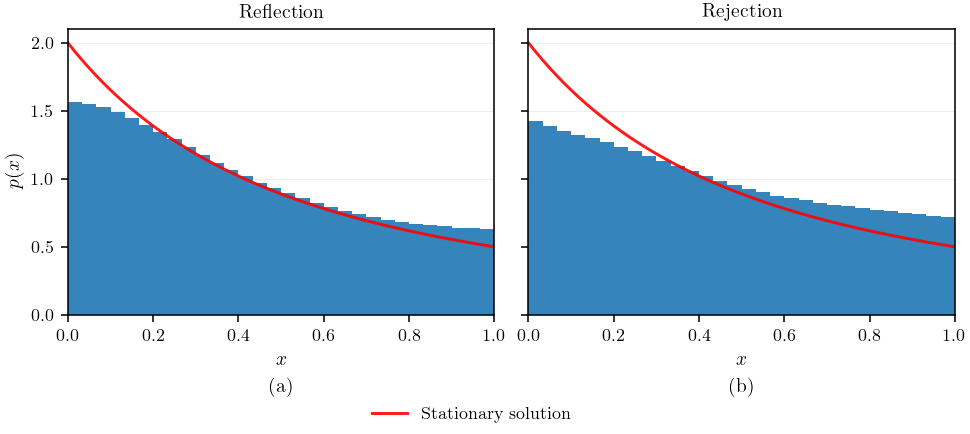

In [11]:
x_plot = np.linspace(x_bounds[0], x_bounds[1], 500)
p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

panel_labels = [r"(a)", r"(b)"]

# Figure-specific scale
figure_scale = 1.0


with mpl.rc_context(scaled_plot_style(figure_scale)):

    for dt in dt_list:

        fig, ax = plt.subplots(
            1, 2,
            figsize=scaled_figsize(
                FIGSIZE_DOUBLE,
                figure_scale
            ),
            sharex=True,
            sharey=True
        )

        stationary_line = None

        for i, boundary_type in enumerate(boundary_types):

            # Load the precomputed solution
            X = load_solution(
                f"{boundary_type}_dt-{dt}.npy",
                problem_path
            )

            # Histogram
            ax[i].hist(
                X,
                bins=30,
                density=True,
                color=COLOR_HISTOGRAM,
                alpha=HISTOGRAM_ALPHA,
                edgecolor="none"
            )

            # Exact stationary solution
            stationary_line, = ax[i].plot(
                x_plot,
                p_exact,
                color=COLOR_STATIONARY,
                alpha=STATIONARY_ALPHA,
                label=r"Stationary solution"
            )

            # Axes formatting
            ax[i].set_title(
                boundary_name[boundary_type]
            )

            ax[i].set_xlabel(r"$x$")
            ax[i].set_xlim(x_bounds)
            ax[i].set_ylim(bottom=0)

            # Horizontal grid only
            ax[i].grid(
                True,
                axis="y"
            )

            # Panel label
            ax[i].text(
                0.5,
                -0.22,
                panel_labels[i],
                transform=ax[i].transAxes,
                ha="center",
                va="top"
            )

        # Shared y-axis label
        ax[0].set_ylabel(r"$p(x)$")

        # Shared legend
        fig.legend(
            handles=[stationary_line],
            labels=[r"Stationary solution"],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=1
        )

        # Layout
        fig.subplots_adjust(
            left=0.10,
            right=0.98,
            top=0.88,
            bottom=0.28,
            wspace=0.08
        )

        # Save
        save_report_figure(
            fig,
            f"b-0_s-xp1_dt-{dt:g}"
        )

        plt.show()
        plt.close(fig)

### b=1 s=1+x

In [12]:
#this is to make sure that lambda functions are deleted before defining new one
for var_name in ['b', 'sigma']:
    if var_name in locals():
        del locals()[var_name]

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions
b = lambda x: constant_drift(x, value=1)
sigma = lambda x: linear_diffusion(x, slope=1, intercept=1) 

#these are used to load generated solutions
problem_path = "./data/b-1_s-xp1"
boundary_types = ["reflection", "rejection"]
dt_list = [0.04]

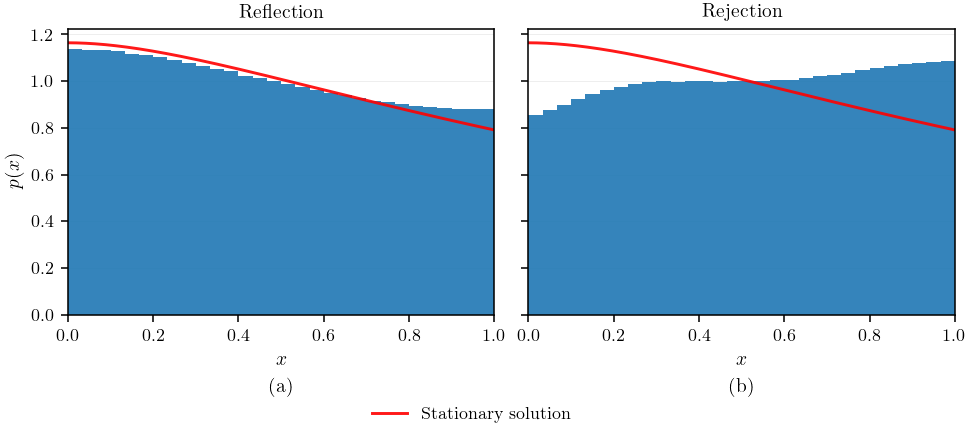

In [13]:
x_plot = np.linspace(x_bounds[0], x_bounds[1], 500)
p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

panel_labels = [r"(a)", r"(b)"]

# Figure-specific scale
figure_scale = 1.0


with mpl.rc_context(scaled_plot_style(figure_scale)):

    for dt in dt_list:

        fig, ax = plt.subplots(
            1, 2,
            figsize=scaled_figsize(
                FIGSIZE_DOUBLE,
                figure_scale
            ),
            sharex=True,
            sharey=True
        )

        stationary_line = None

        for i, boundary_type in enumerate(boundary_types):

            # Load the precomputed solution
            X = load_solution(
                f"{boundary_type}_dt-{dt}.npy",
                problem_path
            )

            # Histogram
            ax[i].hist(
                X,
                bins=30,
                density=True,
                color=COLOR_HISTOGRAM,
                alpha=HISTOGRAM_ALPHA,
                edgecolor="none"
            )

            # Exact stationary solution
            stationary_line, = ax[i].plot(
                x_plot,
                p_exact,
                color=COLOR_STATIONARY,
                alpha=STATIONARY_ALPHA,
                label=r"Stationary solution"
            )

            # Axes formatting
            ax[i].set_title(
                boundary_name[boundary_type]
            )

            ax[i].set_xlabel(r"$x$")
            ax[i].set_xlim(x_bounds)
            ax[i].set_ylim(bottom=0)

            # Horizontal grid only
            ax[i].grid(
                True,
                axis="y"
            )

            # Panel label
            ax[i].text(
                0.5,
                -0.22,
                panel_labels[i],
                transform=ax[i].transAxes,
                ha="center",
                va="top"
            )

        # Shared y-axis label
        ax[0].set_ylabel(r"$p(x)$")

        # Shared legend
        fig.legend(
            handles=[stationary_line],
            labels=[r"Stationary solution"],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=1
        )

        # Layout
        fig.subplots_adjust(
            left=0.10,
            right=0.98,
            top=0.88,
            bottom=0.28,
            wspace=0.08
        )

        # Save
        save_report_figure(
            fig,
            f"b-1_s-xp1_dt-{dt:g}"
        )

        plt.show()
        plt.close(fig)

### full domain plots

In [14]:
#this is to make sure that lambda functions are deleted before defining new one
for var_name in ['b', 'sigma']:
    if var_name in locals():
        del locals()[var_name]

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions
b = lambda x: constant_drift(x, value=0)
sigma = lambda x: linear_diffusion(x, slope=1, intercept=1) 

#these are used to load generated solutions
problem_path = "./data/b-0_s-xp1"
boundary_types = ["reflection", "rejection"]
dt_list = [0.04, 0.0025]

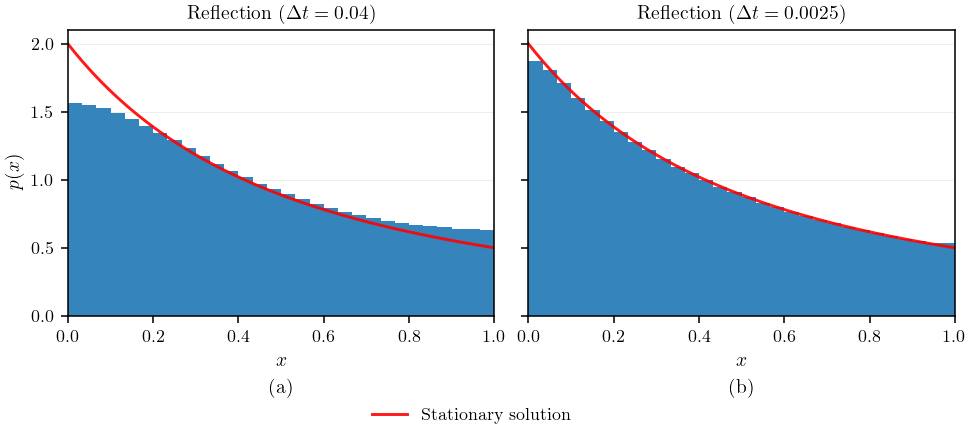

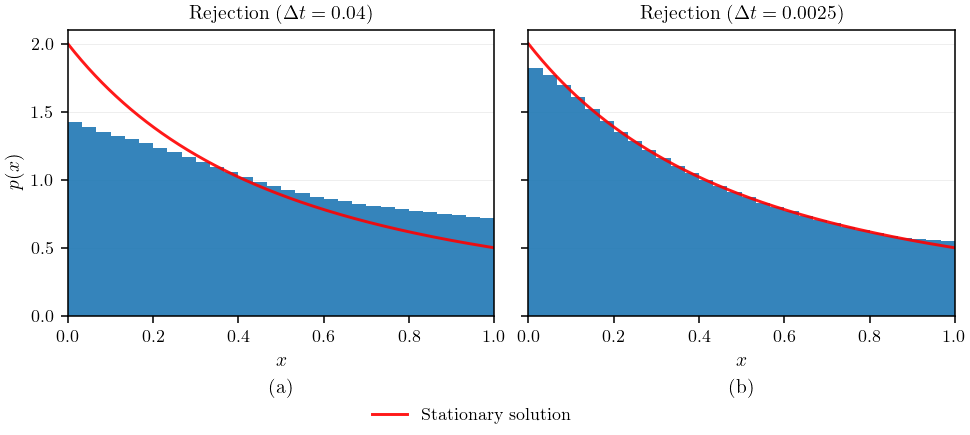

In [15]:
x_plot = np.linspace(x_bounds[0], x_bounds[1], 500)
p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

panel_labels = [r"(a)", r"(b)"]

# Figure-specific scale
figure_scale = 1.0


with mpl.rc_context(scaled_plot_style(figure_scale)):

    for boundary_type in boundary_types:

        fig, ax = plt.subplots(
            1, 2,
            figsize=scaled_figsize(
                FIGSIZE_DOUBLE,
                figure_scale
            ),
            sharex=True,
            sharey=True
        )

        stationary_line = None

        for i, dt in enumerate(dt_list):

            # Load the precomputed solution
            X = load_solution(
                f"{boundary_type}_dt-{dt}.npy",
                problem_path
            )

            # Histogram
            ax[i].hist(
                X,
                bins=30,
                density=True,
                color=COLOR_HISTOGRAM,
                alpha=HISTOGRAM_ALPHA,
                edgecolor="none"
            )

            # Exact stationary solution
            stationary_line, = ax[i].plot(
                x_plot,
                p_exact,
                color=COLOR_STATIONARY,
                alpha=STATIONARY_ALPHA,
                label=r"Stationary solution"
            )

            # Axes formatting
            ax[i].set_title(
                rf"{boundary_name[boundary_type]} "
                rf"($\Delta t = {dt:g}$)"
            )

            ax[i].set_xlabel(r"$x$")
            ax[i].set_xlim(x_bounds)
            ax[i].set_ylim(bottom=0)

            # Horizontal grid only
            ax[i].grid(
                True,
                axis="y"
            )

            # Panel label
            ax[i].text(
                0.5,
                -0.22,
                panel_labels[i],
                transform=ax[i].transAxes,
                ha="center",
                va="top"
            )

        # Shared y-axis label
        ax[0].set_ylabel(r"$p(x)$")

        # Shared legend
        fig.legend(
            handles=[stationary_line],
            labels=[r"Stationary solution"],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=1
        )

        # Layout
        fig.subplots_adjust(
            left=0.10,
            right=0.98,
            top=0.88,
            bottom=0.28,
            wspace=0.08
        )

        # Build filename from all time-step values
        dt_tag = "_".join(f"{dt:g}" for dt in dt_list)

        # Save
        save_report_figure(
            fig,
            f"b-0_s-xp1_{boundary_type}_dt-{dt_tag}"
        )

        plt.show()
        plt.close(fig)

## boundary analysis part

In [16]:
#this is to make sure that lambda functions are deleted before defining new one
for var_name in ['b', 'sigma']:
    if var_name in locals():
        del locals()[var_name]

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions
b = lambda x: constant_drift(x, value=1)
sigma = lambda x: linear_diffusion(x, slope=1, intercept=1) 

#these are used to load generated solutions
problem_path = "./data/b-1_s-xp1"
boundary_types = ["reflection", "rejection"]
dt_list = [0.04, 0.0025]

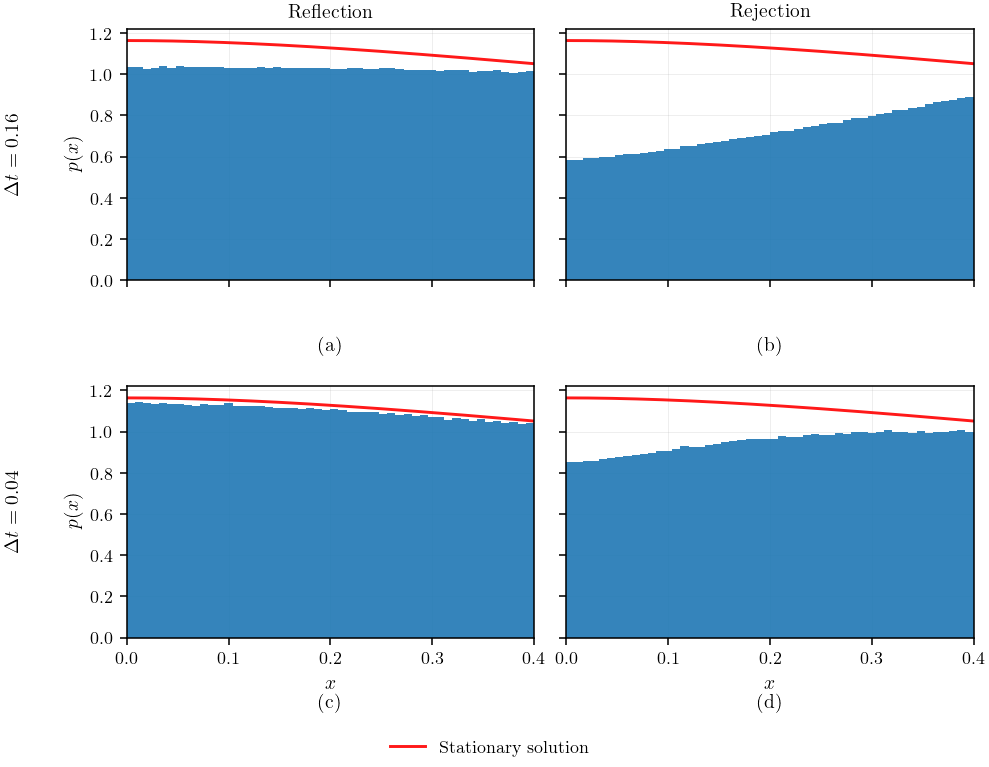

In [17]:
bins = 50
width = 0.4

dt_plot = [0.16, 0.04]
boundary_types_plot = ["reflection", "rejection"]

panel_labels = [
    [r"(a)", r"(b)"],
    [r"(c)", r"(d)"]
]

# Figure-specific scale
figure_scale = 1.0

x_range = (
    x_bounds[0],
    x_bounds[0] + width
)

x_plot = np.linspace(
    x_range[0],
    x_range[1],
    500
)

p_exact = stationary_solution(
    x_plot,
    b,
    sigma,
    x_bounds
)


with mpl.rc_context(scaled_plot_style(figure_scale)):

    fig, ax = plt.subplots(
        2, 2,
        figsize=scaled_figsize(
            (7.2, 5.8),
            figure_scale
        ),
        sharex=True,
        sharey=True
    )

    stationary_line = None

    for i, dt in enumerate(dt_plot):

        for j, boundary_type in enumerate(boundary_types_plot):

            # Load particle positions
            X = load_solution(
                f"{boundary_type}_dt-{dt}.npy",
                problem_path
            )

            # Compute density in the fixed boundary region
            density, centres, counts, edges, bin_widths = histogram_density(
                X=X,
                x_range=x_range,
                bins=bins
            )

            # Plot numerical density
            plot_local_density(
                centres=centres,
                density=density,
                widths=bin_widths,
                ax=ax[i, j],
                title=None,
                x_label="",
                y_label=""
            )

            # Standardise histogram appearance
            for patch in ax[i, j].patches:
                patch.set_facecolor(COLOR_HISTOGRAM)
                patch.set_alpha(HISTOGRAM_ALPHA)
                patch.set_edgecolor("none")

            # Exact stationary solution
            stationary_line, = ax[i, j].plot(
                x_plot,
                p_exact,
                color=COLOR_STATIONARY,
                alpha=STATIONARY_ALPHA,
                label=r"Stationary solution"
            )

            # Axes formatting
            ax[i, j].set_xlim(x_range)
            ax[i, j].set_ylim(bottom=0)

            # Horizontal grid only
            ax[i, j].grid(
                True,
                axis="y"
            )

            # Panel labels
            ax[i, j].text(
                0.5,
                -0.22,
                panel_labels[i][j],
                transform=ax[i, j].transAxes,
                ha="center",
                va="top"
            )

    # Column titles
    ax[0, 0].set_title(r"Reflection")
    ax[0, 1].set_title(r"Rejection")

    # x-axis labels: one per column
    ax[1, 0].set_xlabel(r"$x$")
    ax[1, 1].set_xlabel(r"$x$")

    # y-axis labels: one per row
    ax[0, 0].set_ylabel(r"$p(x)$")
    ax[1, 0].set_ylabel(r"$p(x)$")

    # Row descriptors
    ax[0, 0].annotate(
        r"$\Delta t = 0.16$",
        xy=(-0.28, 0.5),
        xycoords="axes fraction",
        rotation=90,
        va="center",
        ha="center"
    )

    ax[1, 0].annotate(
        r"$\Delta t = 0.04$",
        xy=(-0.28, 0.5),
        xycoords="axes fraction",
        rotation=90,
        va="center",
        ha="center"
    )

    # Shared legend
    fig.legend(
        handles=[stationary_line],
        labels=[r"Stationary solution"],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=1
    )

    # Layout
    fig.subplots_adjust(
        left=0.14,
        right=0.98,
        top=0.93,
        bottom=0.18,
        wspace=0.08,
        hspace=0.42
    )

    # Save
    dt_tag = "_".join(f"{dt:g}" for dt in dt_plot)

    save_report_figure(
        fig,
        f"boundary-0_dt-{dt_tag}"
    )

    plt.show()
    plt.close(fig)

### stretched coordiante error plot

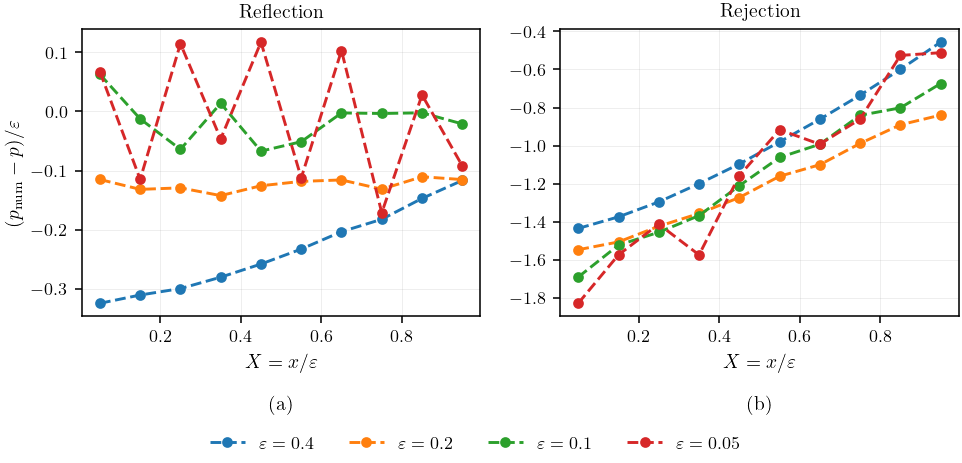

In [18]:
# Analysis settings
bins = 10

dt_plot = [0.16, 0.04, 0.01, 0.0025]

boundary_types_plot = [
    "reflection",
    "rejection"
]

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

panel_labels = [r"(a)", r"(b)"]

# Figure-specific scale
figure_scale = 1.0


with mpl.rc_context(scaled_plot_style(figure_scale)):

    fig, ax = plt.subplots(
        1, 2,
        figsize=scaled_figsize(
            (7.2, 3.6),
            figure_scale
        ),
        sharex=True,
        sharey=False
    )

    for j, boundary_type in enumerate(boundary_types_plot):

        for dt in dt_plot:

            epsilon = np.sqrt(dt)

            # Boundary-layer region [0, epsilon]
            x_range = (
                x_bounds[0],
                x_bounds[0] + epsilon
            )

            # Load particle positions
            X = load_solution(
                f"{boundary_type}_dt-{dt}.npy",
                problem_path
            )

            # Numerical density in the boundary region
            density, centres, counts, edges, bin_widths = histogram_density(
                X=X,
                x_range=x_range,
                bins=bins
            )

            # Stationary density at the same points
            p_exact = stationary_solution(
                centres,
                b,
                sigma,
                x_bounds
            )

            # Stretched coordinate and scaled error
            x_scaled = (
                centres - x_bounds[0]
            ) / epsilon

            error_scaled = (
                density - p_exact
            ) / epsilon

            ax[j].plot(
                x_scaled,
                error_scaled,
                marker="o",
                linestyle="--",
                label=fr"$\varepsilon = {epsilon:g}$"
            )

        # Axes formatting
        ax[j].set_title(
            boundary_name[boundary_type]
        )

        # One x-label under each subplot, with panel label below it
        ax[j].set_xlabel(
            r"$X = x / \varepsilon$" + "\n\n" + panel_labels[j]
        )

        ax[j].grid(
            True
        )

    # Y-axis label
    ax[0].set_ylabel(
        r"$(p_{\mathrm{num}} - p)/\varepsilon$"
    )

    # One shared legend below the panels
    handles, labels = ax[0].get_legend_handles_labels()

    fig.legend(
        handles=handles,
        labels=labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=4
    )

    # Layout
    fig.subplots_adjust(
        left=0.11,
        right=0.98,
        top=0.88,
        bottom=0.31,
        wspace=0.20
    )

    # Save
    save_report_figure(
        fig,
        f"b-1_s-xp1_x-0_error_eps"
    )

    plt.show()
    plt.close(fig)

## error section

### full domain

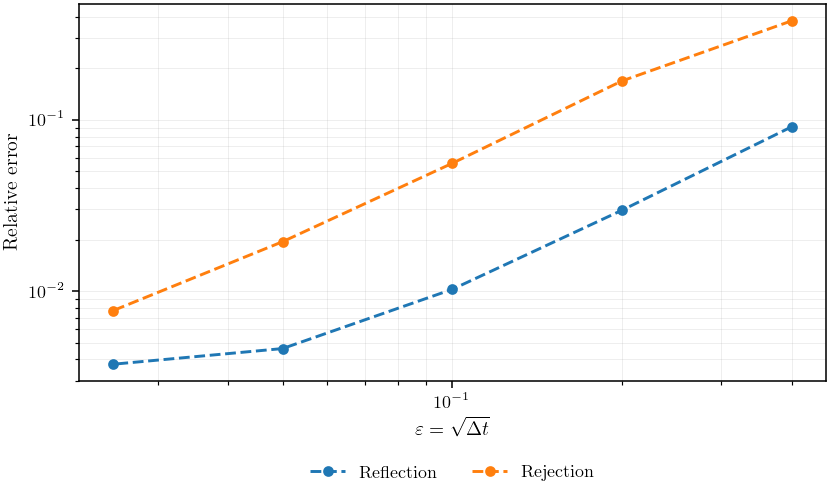

,boundary_type,observed_order
0,Reflection,1.189563
1,Rejection,1.436392


In [19]:
# Analysis settings
bins = 100

dt_plot = [0.16, 0.04, 0.01, 0.0025, 0.000625]

boundary_types_plot = [
    "reflection",
    "rejection"
]

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

boundary_color = {
    "reflection": COLOR_REFLECTION,
    "rejection": COLOR_REJECTION
}

# Convergence variable
epsilon_list = np.sqrt(
    np.array(dt_plot)
)

# Figure-specific scale
figure_scale = 1.0

# Store observed convergence orders
order_rows = []


with mpl.rc_context(scaled_plot_style(figure_scale)):

    fig, ax = plt.subplots(
        figsize=scaled_figsize(
            (6.2, 3.8),
            figure_scale
        )
    )

    for boundary_type in boundary_types_plot:

        errors = []

        for dt in dt_plot:

            # Load precomputed particle positions
            X = load_solution(
                f"{boundary_type}_dt-{dt}.npy",
                problem_path
            )

            # Numerical density over the full domain
            p_num, centres, counts, edges, bin_widths = histogram_density(
                X=X,
                x_range=x_bounds,
                bins=bins
            )

            # Stationary density at the histogram centres
            p_exact = stationary_solution(
                centres,
                b,
                sigma,
                x_bounds
            )

            # Compute error measures
            local_error, L1_error, L2_error, relative_error = density_errors(
                p_num,
                p_exact,
                bin_widths
            )

            # Relative error is used for the convergence analysis
            errors.append(relative_error)

        errors = np.array(errors)

        # Plot convergence
        ax.loglog(
            epsilon_list,
            errors,
            marker="o",
            linestyle="--",
            color=boundary_color[boundary_type],
            label=boundary_name[boundary_type]
        )

        # Observed convergence order
        order = np.polyfit(
            np.log(epsilon_list),
            np.log(errors),
            1
        )[0]

        order_rows.append({
            "boundary_type": boundary_name[boundary_type],
            "observed_order": order
        })

    # Axis labels
    ax.set_xlabel(
        r"$\varepsilon = \sqrt{\Delta t}$"
    )

    ax.set_ylabel(
        r"Relative error"
    )

    # Grid on major and minor log ticks
    ax.grid(
        True,
        which="both"
    )

    # Legend below the plot
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=len(boundary_types_plot)
    )

    # Layout
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        top=0.96,
        bottom=0.25
    )

    # Save
    save_report_figure(
        fig,
        f"convergence_bins-100-{bins}"
    )

    plt.show()
    plt.close(fig)


# Display observed convergence orders
convergence_table = pd.DataFrame(order_rows)

display(convergence_table)

In [20]:
def boundary_gap(X, b, sigma, boundaries, x_range, bins=30):

    p_num, centres, counts, edges, bin_widths = histogram_density(X, x_range, bins)
    p_exact = stationary_solution(centres, b, sigma, boundaries)

    if x_range[0] == boundaries[0]:
        index = 0
    elif x_range[1] == boundaries[1]:
        index = -1

    gap = np.abs(p_num[index] - p_exact[index])

    return gap

### near boundary

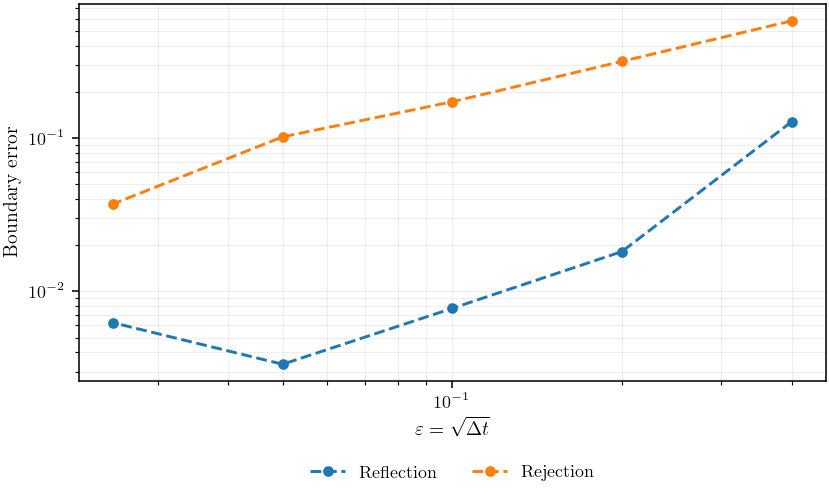

,boundary_type,observed_order
0,Reflection,1.114712
1,Rejection,0.956975


In [21]:
# Analysis settings
bins = 50

dt_plot = [0.16, 0.04, 0.01, 0.0025, 0.000625]

boundary_types_plot = [
    "reflection",
    "rejection"
]

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

boundary_color = {
    "reflection": COLOR_REFLECTION,
    "rejection": COLOR_REJECTION
}

# Left boundary
x_boundary = x_bounds[0]

# Convergence variable
epsilon_list = np.sqrt(
    np.array(dt_plot)
)

# Figure-specific scale
figure_scale = 1.0

# Store observed convergence orders
order_rows = []


with mpl.rc_context(scaled_plot_style(figure_scale)):

    fig, ax = plt.subplots(
        figsize=scaled_figsize(
            (6.2, 3.8),
            figure_scale
        )
    )

    for boundary_type in boundary_types_plot:

        gaps = []

        for dt in dt_plot:

            epsilon = np.sqrt(dt)

            # Boundary-layer region [x_boundary, x_boundary + epsilon]
            x_range = (
                x_boundary,
                x_boundary + epsilon
            )

            # Load precomputed particle positions
            X = load_solution(
                f"{boundary_type}_dt-{dt}.npy",
                problem_path
            )

            # Error in the histogram bin adjacent to the boundary
            gap = boundary_gap(
                X=X,
                b=b,
                sigma=sigma,
                boundaries=x_bounds,
                x_range=x_range,
                bins=bins
            )

            gaps.append(gap)

        gaps = np.array(gaps)

        # Plot boundary error
        ax.loglog(
            epsilon_list,
            gaps,
            marker="o",
            linestyle="--",
            color=boundary_color[boundary_type],
            label=boundary_name[boundary_type]
        )

        # Observed convergence order
        order = np.polyfit(
            np.log(epsilon_list),
            np.log(gaps),
            1
        )[0]

        order_rows.append({
            "boundary_type": boundary_name[boundary_type],
            "observed_order": order
        })

    # Axis labels
    ax.set_xlabel(
        r"$\varepsilon = \sqrt{\Delta t}$"
    )

    ax.set_ylabel(
        r"Boundary error"
    )

    # Grid on major and minor log ticks
    ax.grid(
        True,
        which="both"
    )

    # Legend below the plot
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=len(boundary_types_plot)
    )

    # Layout
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        top=0.96,
        bottom=0.25
    )

    # Save
    save_report_figure(
        fig,
        f"boudary_convergance_bins-{bins}"
    )

    plt.show()
    plt.close(fig)


# Display observed boundary convergence orders
boundary_convergence_table = pd.DataFrame(order_rows)

display(boundary_convergence_table)

## bins plot

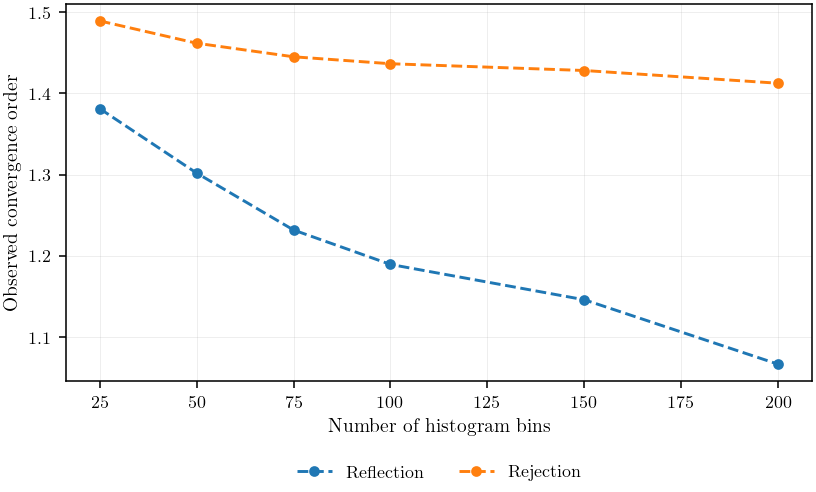

,bins,boundary_type,observed_order
0,25,Reflection,1.381272
1,25,Rejection,1.489111
2,50,Reflection,1.301971
3,50,Rejection,1.461641
4,75,Reflection,1.231930
5,75,Rejection,1.444938
6,100,Reflection,1.189563
7,100,Rejection,1.436392
8,150,Reflection,1.146097
9,150,Rejection,1.428062


In [22]:
# Analysis settings
bins_plot = [25, 50, 75, 100, 150, 200]

dt_plot = [0.16, 0.04, 0.01, 0.0025, 0.000625]

boundary_types_plot = [
    "reflection",
    "rejection"
]

boundary_name = {
    "reflection": "Reflection",
    "rejection": "Rejection"
}

boundary_color = {
    "reflection": COLOR_REFLECTION,
    "rejection": COLOR_REJECTION
}

epsilon_list = np.sqrt(
    np.array(dt_plot)
)

# Figure-specific scale
figure_scale = 1.0

# Store observed orders
order_rows = []


# ============================================================
# Compute observed convergence orders
# ============================================================

for bins in bins_plot:

    for boundary_type in boundary_types_plot:

        errors = []

        for dt in dt_plot:

            # Load precomputed particle positions
            X = load_solution(
                f"{boundary_type}_dt-{dt}.npy",
                problem_path
            )

            # Numerical density over the full domain
            p_num, centres, counts, edges, bin_widths = histogram_density(
                X=X,
                x_range=x_bounds,
                bins=bins
            )

            # Stationary density
            p_exact = stationary_solution(
                centres,
                b,
                sigma,
                x_bounds
            )

            # Error measures
            local_error, L1_error, L2_error, relative_error = density_errors(
                p_num,
                p_exact,
                bin_widths
            )

            errors.append(relative_error)

        errors = np.array(errors)

        # Observed convergence order
        order = np.polyfit(
            np.log(epsilon_list),
            np.log(errors),
            1
        )[0]

        order_rows.append({
            "bins": bins,
            "boundary_type": boundary_name[boundary_type],
            "observed_order": order
        })


# Results table
bin_convergence_table = pd.DataFrame(order_rows)


# ============================================================
# Plot observed order against number of bins
# ============================================================

with mpl.rc_context(scaled_plot_style(figure_scale)):

    fig, ax = plt.subplots(
        figsize=scaled_figsize(
            (6.2, 3.8),
            figure_scale
        )
    )

    for boundary_type in boundary_types_plot:

        data = bin_convergence_table[
            bin_convergence_table["boundary_type"]
            == boundary_name[boundary_type]
        ]

        ax.plot(
            data["bins"],
            data["observed_order"],
            marker="o",
            linestyle="--",
            color=boundary_color[boundary_type],
            label=boundary_name[boundary_type]
        )

    # Axis labels
    ax.set_xlabel(
        r"Number of histogram bins"
    )

    ax.set_ylabel(
        r"Observed convergence order"
    )

    # Grid
    ax.grid(
        True
    )

    # Legend below the plot
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=len(boundary_types_plot)
    )

    # Layout
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        top=0.96,
        bottom=0.25
    )

    # Save
    save_report_figure(
        fig,
        "bin_error_ref_rej"
    )

    plt.show()
    plt.close(fig)


# Display results table
display(bin_convergence_table)

## mixed and half step

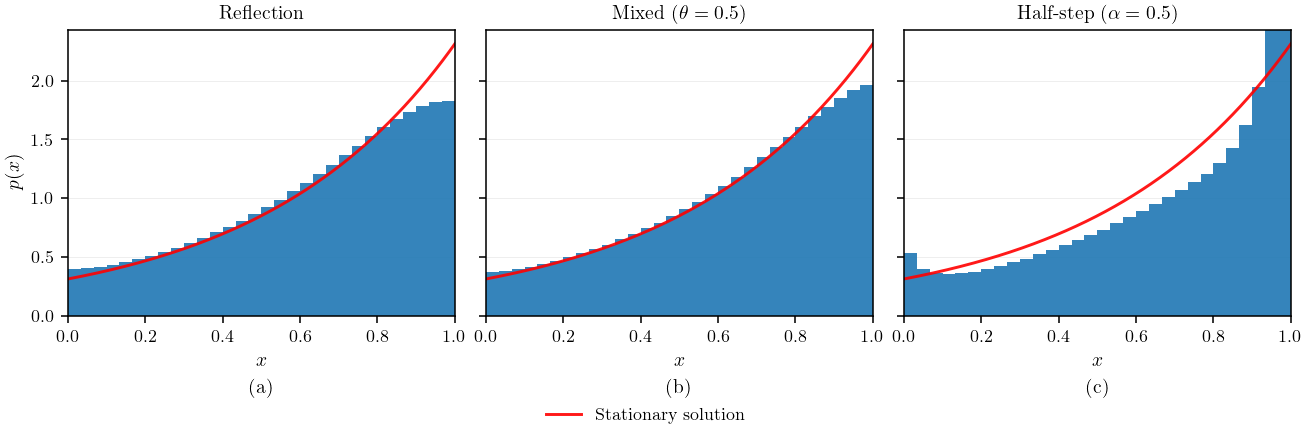

In [23]:
# This is to make sure that lambda functions are deleted before defining new ones
for var_name in ["b", "sigma"]:
    if var_name in locals():
        del locals()[var_name]


# Set the boundaries
x_bounds = (0, 1)


# Drift and diffusion as functions
b = lambda x: constant_drift(x, value=1)
sigma = lambda x: constant_diffusion(x, value=1)


# These are used to load generated solutions
problem_path = "./data/b-1_s-1"


scheme_types = [
    "reflection",
    "theta-0.5",
    "half-step"
]

scheme_name = {
    "reflection": "Reflection",
    "theta-0.5": r"Mixed $(\theta = 0.5)$",
    "half-step": r"Half-step $(\alpha = 0.5)$"
}

panel_labels = [
    r"(a)",
    r"(b)",
    r"(c)"
]

dt_list = [0.04]


# Figure-specific scale
figure_scale = 1.0


x_plot = np.linspace(
    x_bounds[0],
    x_bounds[1],
    500
)

p_exact = stationary_solution(
    x_plot,
    b,
    sigma,
    x_bounds
)


with mpl.rc_context(scaled_plot_style(figure_scale)):

    for dt in dt_list:

        fig, ax = plt.subplots(
            1, 3,
            figsize=scaled_figsize(
                (9.6, 3.4),
                figure_scale
            ),
            sharex=True,
            sharey=True
        )

        stationary_line = None

        for i, scheme_type in enumerate(scheme_types):

            # Load the precomputed solution
            X = load_solution(
                f"{scheme_type}_dt-{dt}.npy",
                problem_path
            )

            # Histogram
            ax[i].hist(
                X,
                bins=30,
                density=True,
                color=COLOR_HISTOGRAM,
                alpha=HISTOGRAM_ALPHA,
                edgecolor="none"
            )

            # Exact stationary solution
            stationary_line, = ax[i].plot(
                x_plot,
                p_exact,
                color=COLOR_STATIONARY,
                alpha=STATIONARY_ALPHA,
                label=r"Stationary solution"
            )

            # Axes formatting
            ax[i].set_title(
                scheme_name[scheme_type]
            )

            ax[i].set_xlabel(r"$x$")
            ax[i].set_xlim(x_bounds)
            ax[i].set_ylim(bottom=0)

            # Horizontal grid only
            ax[i].grid(
                True,
                axis="y"
            )

            # Panel label
            ax[i].text(
                0.5,
                -0.22,
                panel_labels[i],
                transform=ax[i].transAxes,
                ha="center",
                va="top"
            )

        # Shared y-axis label
        ax[0].set_ylabel(r"$p(x)$")

        # Shared legend
        fig.legend(
            handles=[stationary_line],
            labels=[r"Stationary solution"],
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            ncol=1
        )

        # Layout
        fig.subplots_adjust(
            left=0.07,
            right=0.98,
            top=0.88,
            bottom=0.28,
            wspace=0.08
        )

        # Save
        save_report_figure(
            fig,
            f"ref_mixed_half_dt-{dt:g}"
        )

        plt.show()
        plt.close(fig)

### mixed only

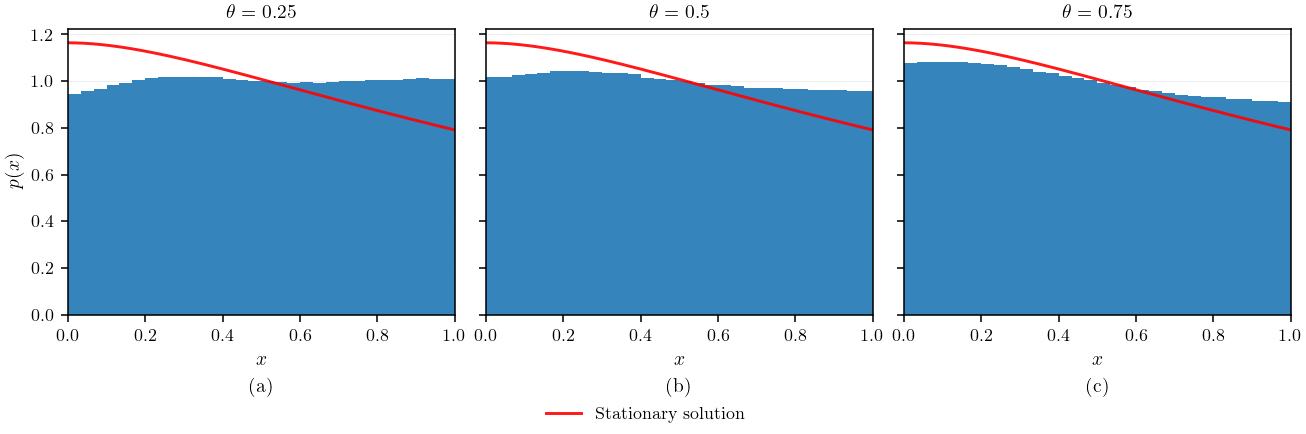

In [24]:
# This is to make sure that lambda functions are deleted before defining new ones
for var_name in ["b", "sigma"]:
    if var_name in locals():
        del locals()[var_name]


# Set the boundaries
x_bounds = (0, 1)


# Drift and diffusion as functions
b = lambda x: constant_drift(x, value=1)
sigma = lambda x: linear_diffusion(x, slope=1, intercept=1)


# These are used to load generated solutions
problem_path = "./data/b-1_s-xp1"


scheme_types = [
    "theta-0.25",
    "theta-0.5",
    "theta-0.75"
]

scheme_name = {
    "theta-0.25": r"$\theta = 0.25$",
    "theta-0.5": r"$\theta = 0.5$",
    "theta-0.75": r"$\theta = 0.75$"
}

panel_labels = [
    r"(a)",
    r"(b)",
    r"(c)"
]


# Time step
dt = 0.04


# Figure-specific scale
figure_scale = 1.0


# Stationary solution
x_plot = np.linspace(
    x_bounds[0],
    x_bounds[1],
    500
)

p_exact = stationary_solution(
    x_plot,
    b,
    sigma,
    x_bounds
)


with mpl.rc_context(scaled_plot_style(figure_scale)):

    fig, ax = plt.subplots(
        1, 3,
        figsize=scaled_figsize(
            (9.6, 3.4),
            figure_scale
        ),
        sharex=True,
        sharey=True
    )

    stationary_line = None

    for i, scheme_type in enumerate(scheme_types):

        # Load the precomputed solution
        X = load_solution(
            f"{scheme_type}_dt-{dt}.npy",
            problem_path
        )

        # Histogram
        ax[i].hist(
            X,
            bins=30,
            density=True,
            color=COLOR_HISTOGRAM,
            alpha=HISTOGRAM_ALPHA,
            edgecolor="none"
        )

        # Exact stationary solution
        stationary_line, = ax[i].plot(
            x_plot,
            p_exact,
            color=COLOR_STATIONARY,
            alpha=STATIONARY_ALPHA,
            label=r"Stationary solution"
        )

        # Axes formatting
        ax[i].set_title(
            scheme_name[scheme_type]
        )

        ax[i].set_xlabel(r"$x$")
        ax[i].set_xlim(x_bounds)
        ax[i].set_ylim(bottom=0)

        # Horizontal grid only
        ax[i].grid(
            True,
            axis="y"
        )

        # Panel label
        ax[i].text(
            0.5,
            -0.22,
            panel_labels[i],
            transform=ax[i].transAxes,
            ha="center",
            va="top"
        )

    # Shared y-axis label
    ax[0].set_ylabel(r"$p(x)$")

    # Shared legend
    fig.legend(
        handles=[stationary_line],
        labels=[r"Stationary solution"],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=1
    )

    # Layout
    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.88,
        bottom=0.28,
        wspace=0.08
    )

    # Save
    save_report_figure(
        fig,
        f"b-1_s-xp1_mixed-{dt:g}"
    )

    plt.show()
    plt.close(fig)